<a href="https://colab.research.google.com/github/deekshasoota/ai-vs_human_text/blob/main/pbl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

path = kagglehub.dataset_download("shanegerami/ai-vs-human-text")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ai-vs-human-text' dataset.
Path to dataset files: /kaggle/input/ai-vs-human-text


In [ ]:
import os

print("Dataset files are located in:", path)
print("Files in the dataset directory:", os.listdir(path))

Dataset files are located in: /kaggle/input/ai-vs-human-text
Files in the dataset directory: ['AI_Human.csv']


In [ ]:
import pandas as pd
import os

data = pd.read_csv(os.path.join(path, "AI_Human.csv"))

# Inspect data
print(data.head())
print(data['generated'].value_counts())

                                                text  generated
0  Cars. Cars have been around since they became ...        0.0
1  Transportation is a large necessity in most co...        0.0
2  "America's love affair with it's vehicles seem...        0.0
3  How often do you ride in a car? Do you drive a...        0.0
4  Cars are a wonderful thing. They are perhaps o...        0.0
generated
0.0    305797
1.0    181438
Name: count, dtype: int64


In [ ]:
X = data['text']  # Text column
y = data['generated'] # Labels (0 = Human, 1 = AI or vice versa)

# Optional: lowercase
X = X.str.lower()

In [ ]:
# Check for duplicates
print("Total rows:", len(data))
print("Unique rows:", len(data.drop_duplicates()))

Total rows: 487235
Unique rows: 487235


In [ ]:
data = data.drop_duplicates(subset='text')

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize text
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

Baseline Accuracy: 0.9934528512935237
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99     61112
         1.0       1.00      0.99      0.99     36335

    accuracy                           0.99     97447
   macro avg       0.99      0.99      0.99     97447
weighted avg       0.99      0.99      0.99     97447



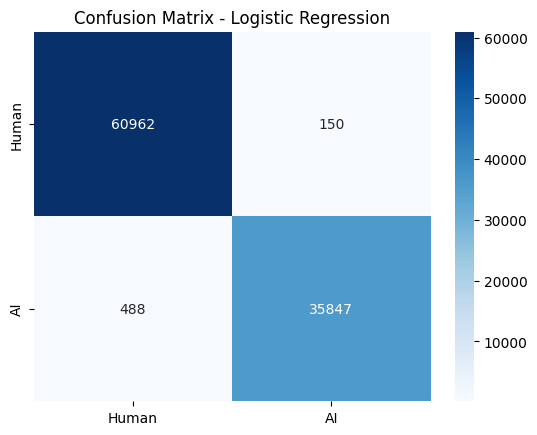

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vect, y_train)

y_pred = model.predict(X_test_vect)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Human","AI"], yticklabels=["Human","AI"])
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# Convert pandas to HuggingFace Dataset
hf_dataset = Dataset.from_pandas(pd.DataFrame({'text': X, 'label': y}))
hf_dataset = hf_dataset.train_test_split(test_size=0.2, seed=42)

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize(batch):
    return tokenizer(batch['text'], padding=True, truncation=True, max_length=256)

hf_dataset = hf_dataset.map(tokenize, batched=True)
hf_dataset.set_format(type='torch', columns=['input_ids','attention_mask','label'])

# Model
model = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=2)

# Training arguments
training_args = TrainingArguments(
    output_dir="./roberta_results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./roberta_logs",
    load_best_model_at_end=True,
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=hf_dataset['train'],
    eval_dataset=hf_dataset['test'],
    tokenizer=tokenizer
)

trainer.train()

In [ ]:
results = trainer.evaluate()
print(results)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import torch
import numpy as np

baseline_acc = accuracy_score(y_test, y_pred)
roberta_acc = results['eval_accuracy']  # from trainer.evaluate()

plt.figure(figsize=(6,4))
plt.bar(["Logistic Regression", "RoBERTa"], [baseline_acc, roberta_acc], color=['skyblue','orange'])
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

In [ ]:
# Logistic Regression CM
cm_baseline = confusion_matrix(y_test, y_pred)

# RoBERTa predictions
from torch.nn.functional import softmax

# Prepare inputs for RoBERTa evaluation
inputs = tokenizer(list(X_test), padding=True, truncation=True, max_length=256, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
    probs = softmax(outputs.logits, dim=1)
    roberta_preds = torch.argmax(probs, dim=1).numpy()

cm_roberta = confusion_matrix(y_test, roberta_preds)

fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap="Blues", ax=axes[0], xticklabels=["Human","AI"], yticklabels=["Human","AI"])
axes[0].set_title("Logistic Regression CM")
sns.heatmap(cm_roberta, annot=True, fmt='d', cmap="Greens", ax=axes[1], xticklabels=["Human","AI"], yticklabels=["Human","AI"])
axes[1].set_title("RoBERTa CM")
plt.show()

In [ ]:
from sklearn.preprocessing import label_binarize

# Binarize labels
y_test_bin = label_binarize(y_test, classes=[0,1])

# Logistic Regression probabilities
y_pred_proba_baseline = model.predict_proba(X_test_vect)[:,1]

# RoBERTa probabilities
y_pred_proba_roberta = probs[:,1].numpy()

# Compute ROC curve
fpr_baseline, tpr_baseline, _ = roc_curve(y_test_bin, y_pred_proba_baseline)
roc_auc_baseline = auc(fpr_baseline, tpr_baseline)

fpr_roberta, tpr_roberta, _ = roc_curve(y_test_bin, y_pred_proba_roberta)
roc_auc_roberta = auc(fpr_roberta, tpr_roberta)

plt.figure(figsize=(6,5))
plt.plot(fpr_baseline, tpr_baseline, color='blue', label=f'LogReg (AUC = {roc_auc_baseline:.2f})')
plt.plot(fpr_roberta, tpr_roberta, color='green', label=f'RoBERTa (AUC = {roc_auc_roberta:.2f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()